Advanced Hybrid Machine Learning Model for Accurate
Detection of Cardiovascular Disease

In [ ]:
!pip install pyartemis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pa

In [ ]:
!pip install alibi

In [ ]:
!pip install lime shap scikit-learn numpy pandas matplotlib tensorflow pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.3 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=154b6ae7912f77332aca198e32d4d51f8627f34135b94c0948d842aee375847c
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
  Attempting uninstall: networkx
    Found existing installation: networkx 2.8.8
    Uninstalling networkx-2.8.8:
      Successfully uninstalled networkx-2.8.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyartemis 0.1.5 requires networkx<3.0.0,>=2.8.8, but you have networkx 3.4.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" an

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, LSTM
from tensorflow.keras.layers import Flatten, Dropout, Dense
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [ ]:
from lime.lime_tabular import LimeTabularExplainer


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.combine import SMOTEENN

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression


In [ ]:
from alibi.explainers import ALE , plot_ale

In [ ]:
df=pd.read_csv('cardio_train.csv',sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
print(df.duplicated().sum())
print("_________________________________________________________________")
print(df.isnull().sum())
print("_________________________________________________________________")

print(df.info())
print("_______________________________________________________________")

print(df.describe())
df['age'] = df['age']/ 365
df.drop("id",axis=1,inplace= True)

0
_________________________________________________________________
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
_________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         7

3.2 Data Preprocessing

- 3.2.1 Data Cleaning

In [ ]:
# data cleaning
df.isna().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


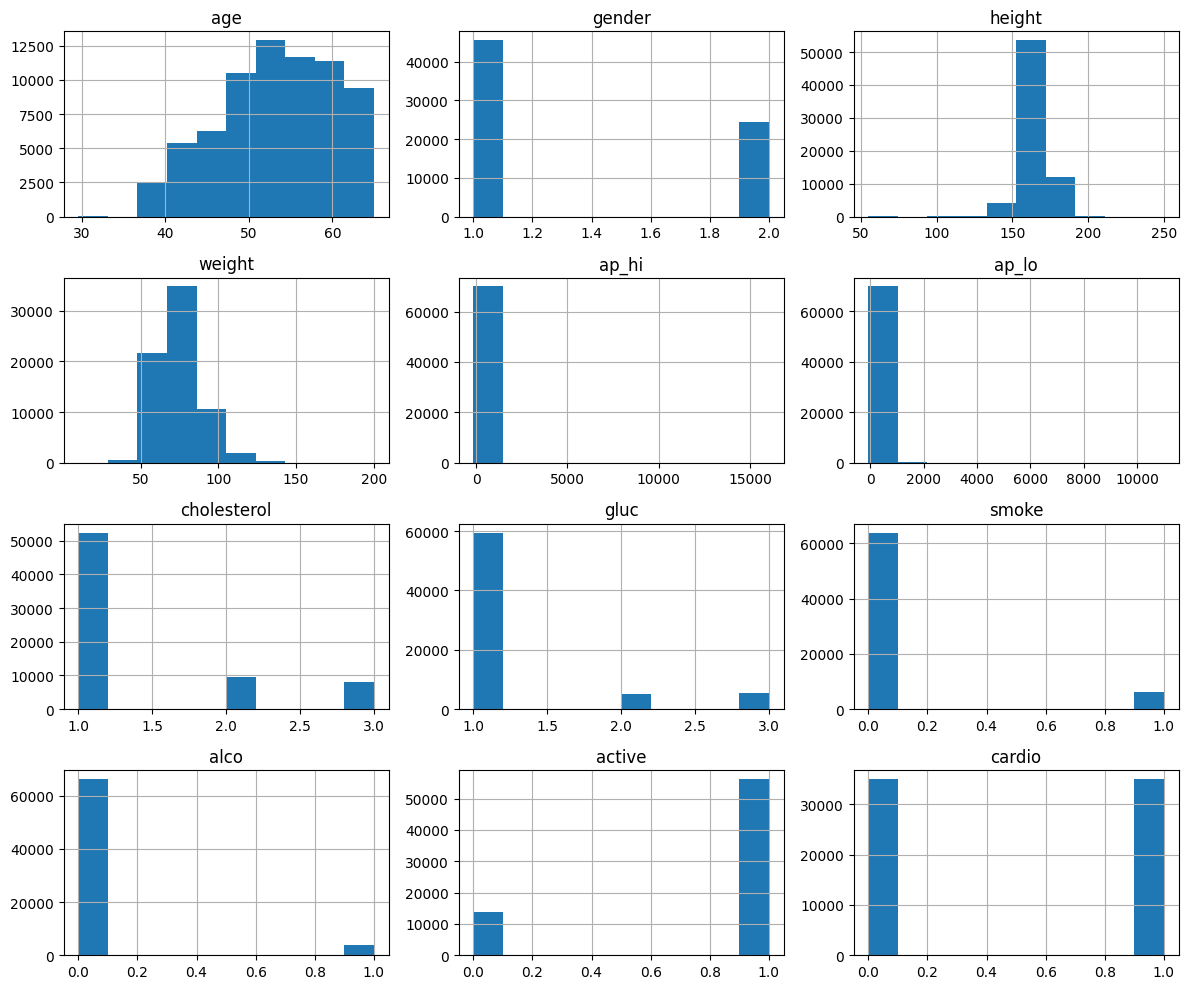

In [ ]:
#  distribution of data along each feature
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

In [ ]:
#  the min–max scaling method is followed to normalize the dataduring the pre-processing phase
scaler = MinMaxScaler()
features = df.drop(columns=['cardio'])
scaled_features = scaler.fit_transform(features)
X = pd.DataFrame(scaled_features, columns=features.columns)
y = df['cardio']


- 3.2.2 Data Balancing

<Axes: xlabel='cardio', ylabel='count'>

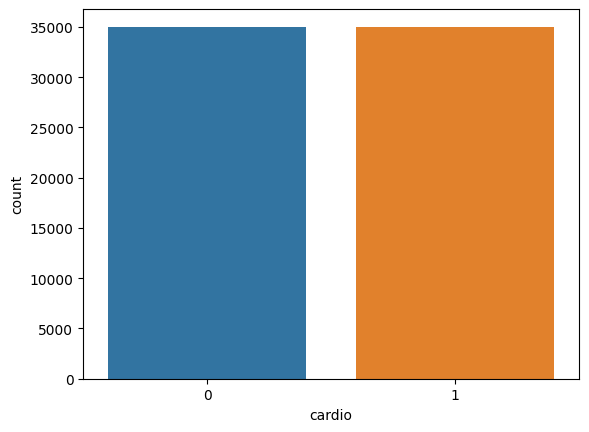

In [ ]:
sns.countplot(x=y)


the classes of the target is nearly balanced but we will apply (SMOTE–ENN) approach as he did in the reseach proposed model to makesure from balance of our dataset

In [ ]:
smotenn = SMOTEENN(random_state=42)
Xresample, yresample = smotenn.fit_resample(X, y)


Feature Selection (FS)

In our proposed model, we employed Chi-square

In [ ]:
chi = SelectKBest(score_func=chi2, k='all')
Xchi = chi.fit_transform(Xresample, yresample)


Data split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(Xchi, yresample, test_size=0.2, random_state=42)


3.4 Machine Learning Techniques

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
accuracy_score(y_test, knn.predict(X_test))


0.9191607528540574

In [ ]:

ab = AdaBoostClassifier(random_state=42)
ab.fit(X_train, y_train)
accuracy_score(y_test, ab.predict(X_test))


0.9021906818883061

3.4.7 Stacking Ensemble

In [ ]:
stack = StackingClassifier(
    estimators=[('random forest', RandomForestClassifier(random_state=42)),('knn', knn),('ada', ab)],
    final_estimator=LogisticRegression(),cv=5)
stack.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('random forest',
                                RandomForestClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('ada', AdaBoostClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [ ]:
ypredict=stack.predict(X_test)
print("the proposed model accuracy:", accuracy_score(y_test, ypredict)*100,"%")


the proposed model accuracy: 93.42795433508176 %


In [ ]:
print("_______ classification report__________________________\n", classification_report(y_test, ypredict))


_______ classification report__________________________
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      1617
           1       0.94      0.93      0.93      1624

    accuracy                           0.93      3241
   macro avg       0.93      0.93      0.93      3241
weighted avg       0.93      0.93      0.93      3241



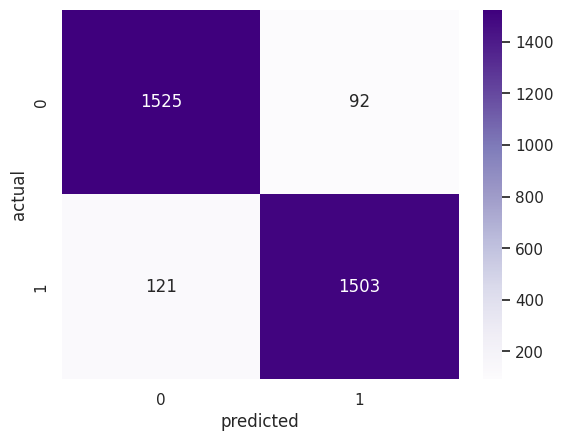

In [ ]:
sns.heatmap(confusion_matrix(y_test, ypredict), annot=True, fmt='d', cmap='Purples')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()


**explainability techniques**

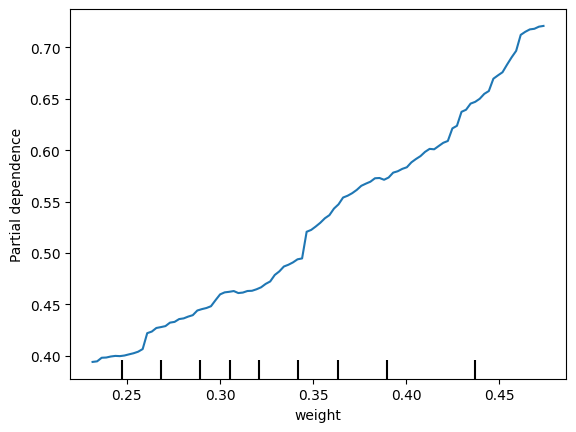

In [24]:
from sklearn.datasets import make_hastie_10_2
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
feature = ['age','gender',	'height',	'weight','ap_hi','ap_lo','cholesterol','gluc','smoke','alco'	,'active']
features = [3]
PartialDependenceDisplay.from_estimator(stack , X_test, features,feature_names=feature);

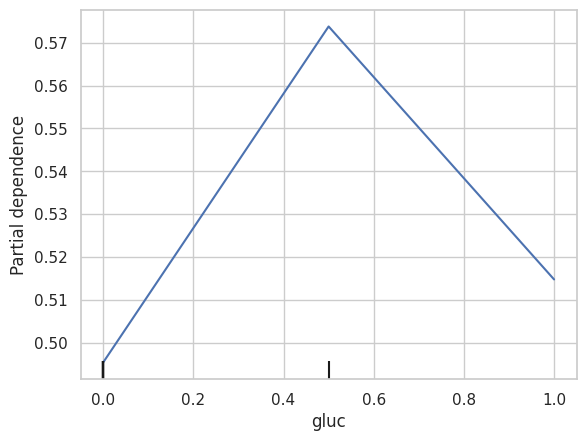

In [ ]:
features = [7]


PartialDependenceDisplay.from_estimator(stack,X_test,features,feature_names=feature);

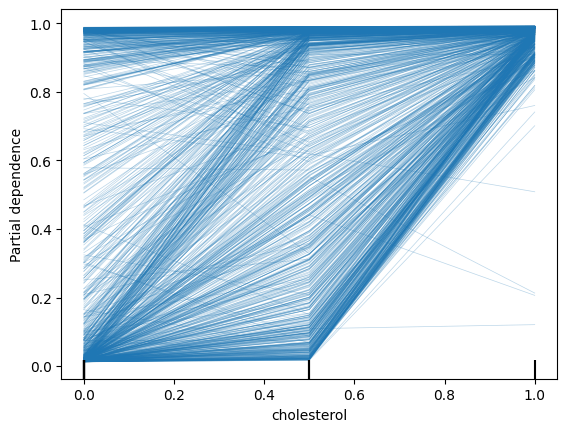

In [25]:
from sklearn.inspection import PartialDependenceDisplay

features = [6]
PartialDependenceDisplay.from_estimator(stack,X_test,features,feature_names=feature,kind="individual")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py", line 63, in inner_f
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_stacking.py", line 717, in fit
    return super().fit(X, y_encoded, **fit_params)
           ^

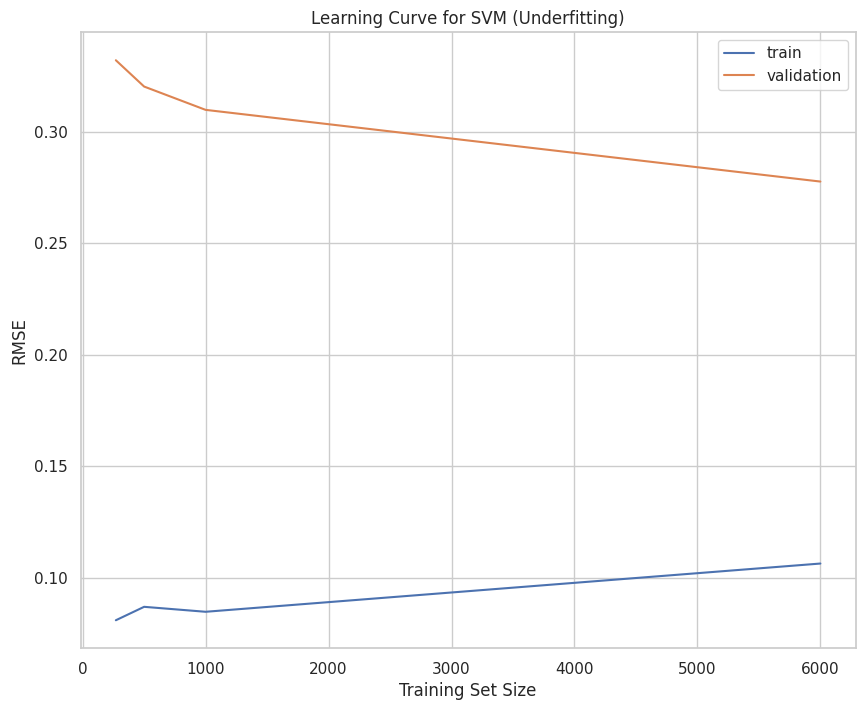

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(estimator=stack, X=X_train,y=y_train,cv=5,scoring="neg_root_mean_squared_error",
    train_sizes = [1, 270,500,1000,6000]
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.subplots(figsize=(10,8))
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, test_mean, label="validation")

plt.title("Learning Curve for SVM (Underfitting)")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")

plt.show();

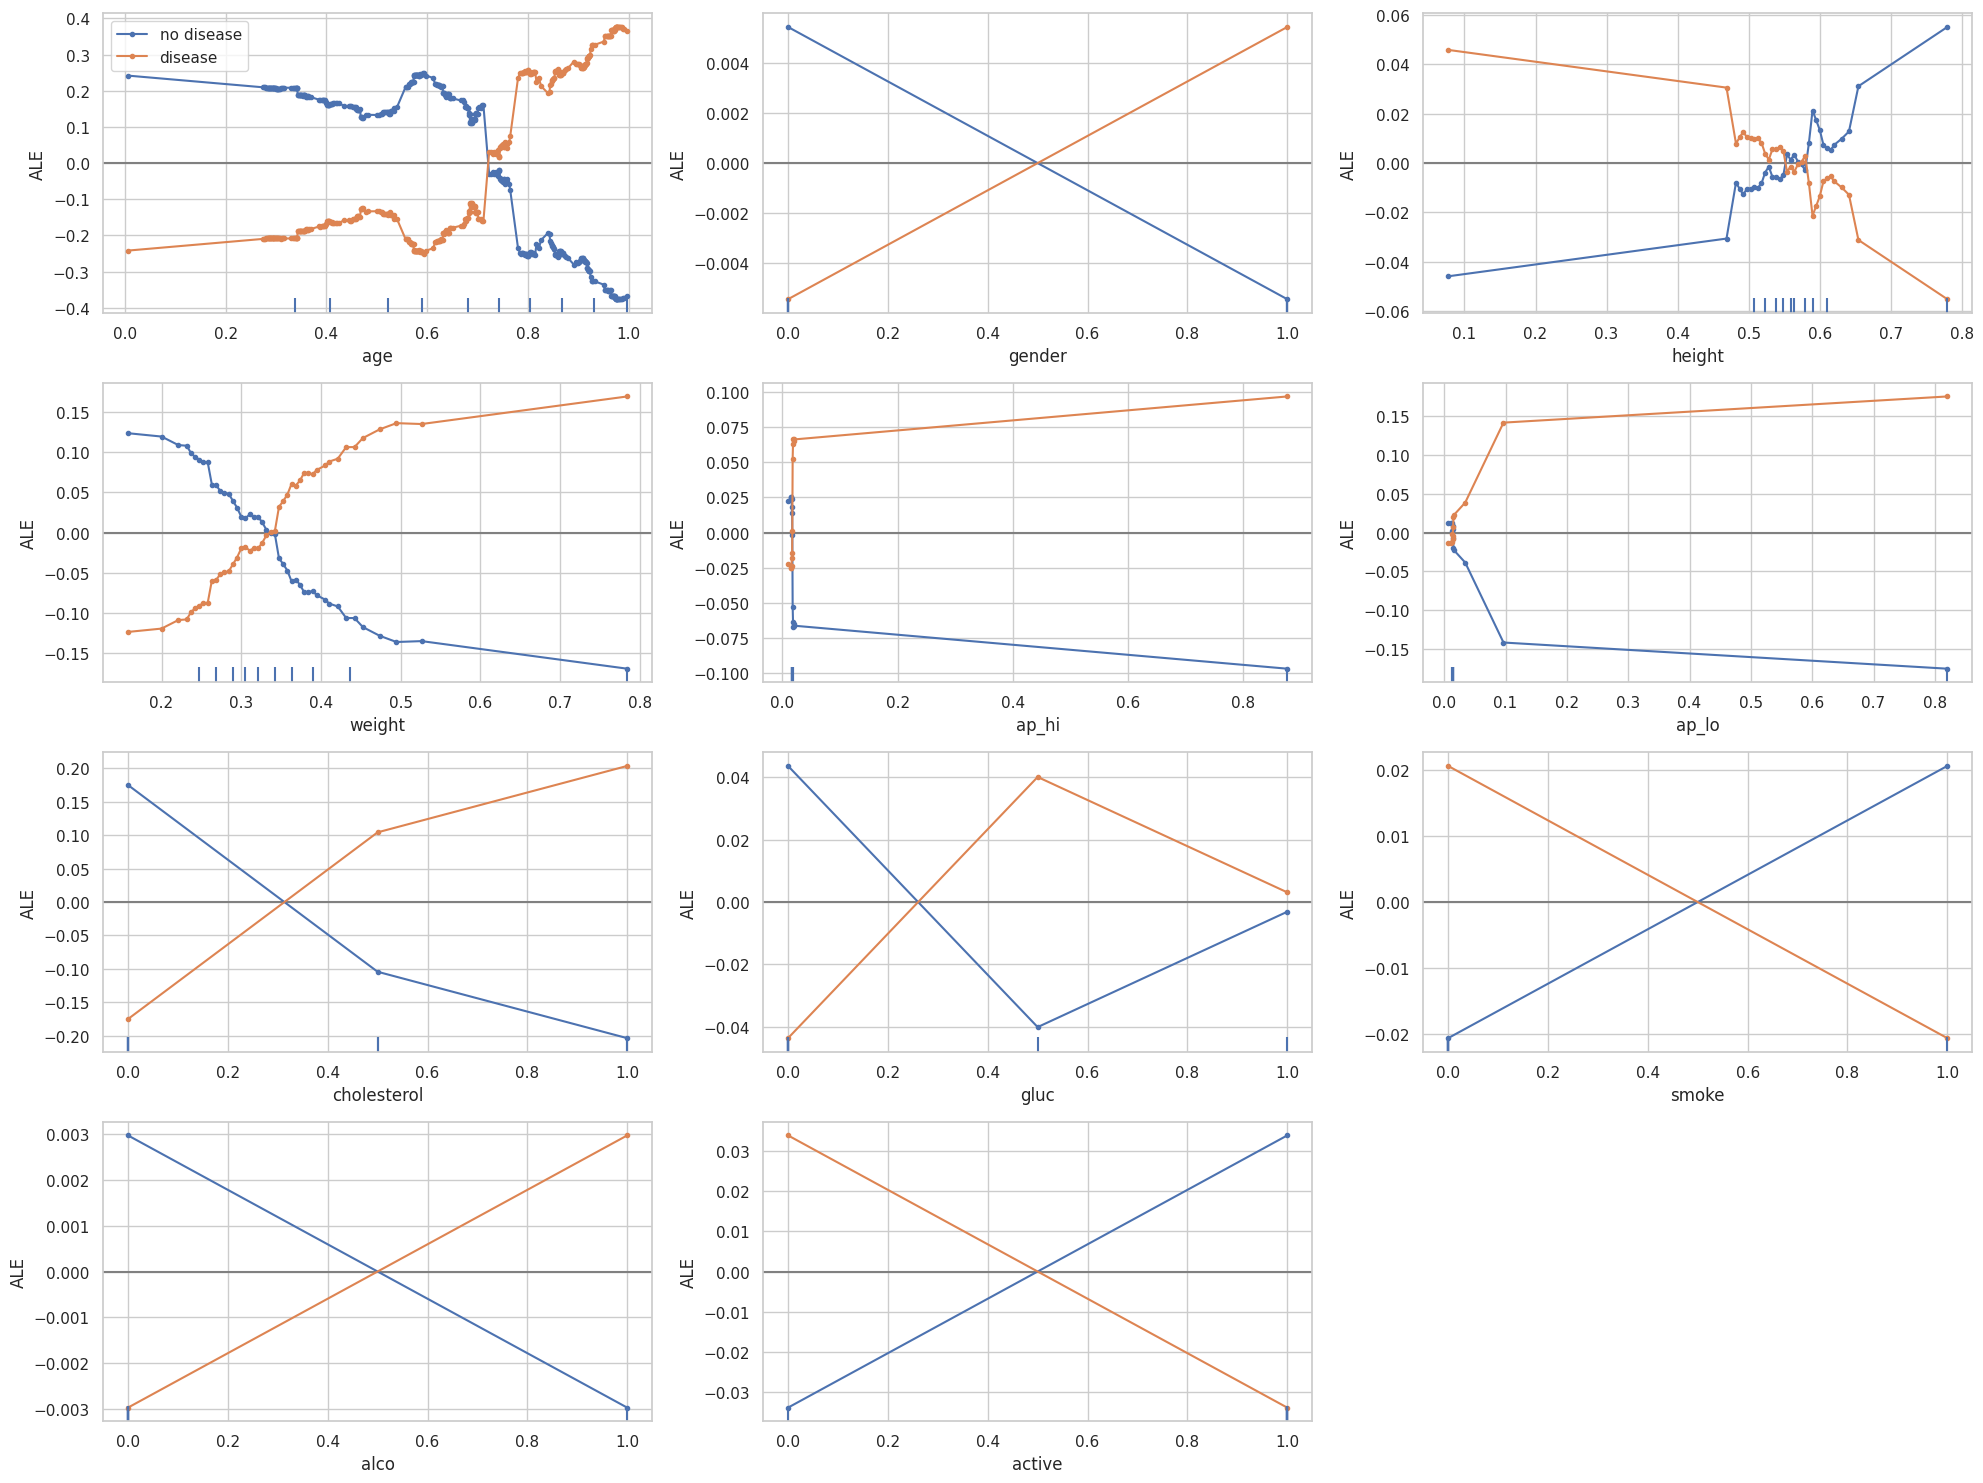

In [ ]:
prob = stack.predict_proba
ALEprob = ALE(prob, feature_names=feature)

exp = ALEprob.explain(X_test)
plot_ale(exp,targets=[0, 1],line_kw={"label": ["no disease", "disease"]},fig_kw={'figwidth': 20, 'figheight': 15},sharey=None);

In [ ]:
x_train = np.array(X_train)
x_test = np.array(X_test)
explainer =LimeTabularExplainer(training_data=x_train,feature_names=feature,class_names=['no_disease', 'disease'],mode='classification')
prob = stack.predict_proba
i = 0
explanation= explainer.explain_instance(data_row=x_test[i],predict_fn=prob, num_features=10
)


In [ ]:
dir(explanation)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'as_html',
 'as_list',
 'as_map',
 'as_pyplot_figure',
 'available_labels',
 'class_names',
 'domain_mapper',
 'intercept',
 'local_exp',
 'local_pred',
 'mode',
 'predict_proba',
 'random_state',
 'save_to_file',
 'score',
 'show_in_notebook',
 'top_labels']

In [ ]:
explanation.show_in_notebook()


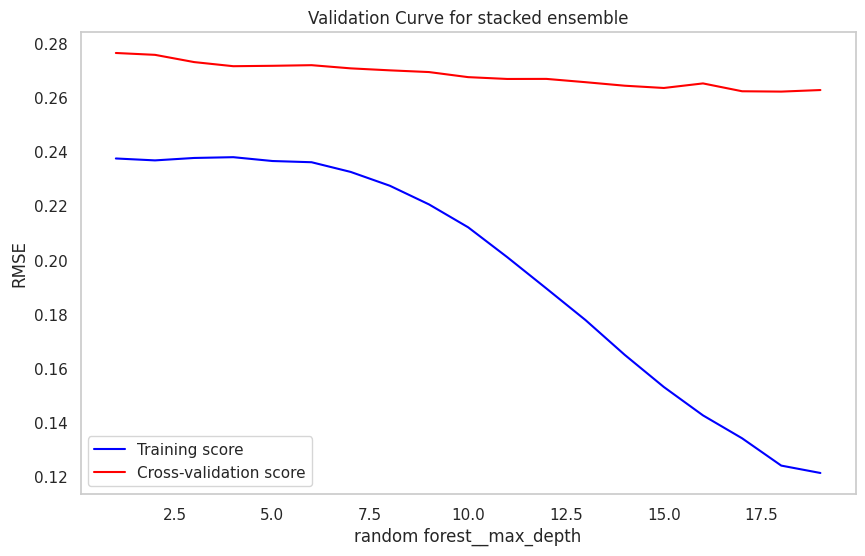

In [ ]:
from sklearn.model_selection import validation_curve

def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5, scoring="neg_root_mean_squared_error"):
    train_scores, test_scores = validation_curve(
        estimator=estimator,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring
    )

    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="Training score", color="blue")
    plt.plot(param_range, test_mean, label="Cross-validation score", color="red")

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("RMSE")
    plt.legend(loc="best")
    plt.grid()
    plt.show()
param_range = np.arange(1, 20)
plot_validation_curve(stack, "Validation Curve for stacked ensemble", X_train, y_train, "random forest__max_depth", param_range)

In [ ]:
from sklearn.model_selection import cross_val_score

baseline = cross_val_score(stack, X_train, y_train, cv=5).mean()



In [ ]:
X_train = pd.DataFrame(X_train, columns=X.columns)

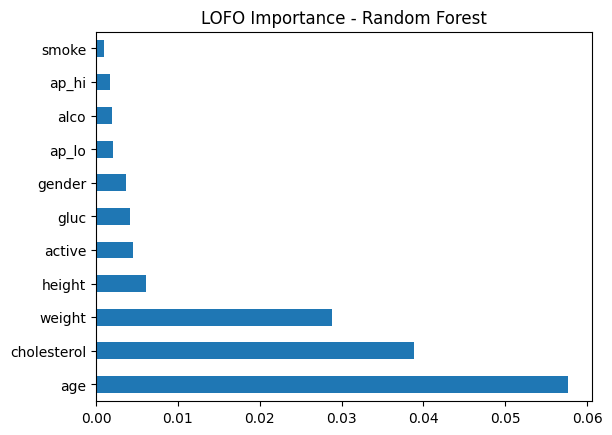

In [ ]:
lofo_scores = {}
for col in X_train.columns:
    X_lofo = X_train.drop(columns=[col])
    score = cross_val_score(stack, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score

lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)
lofo_df.plot(kind='barh')
plt.title("LOFO Importance")
plt.show()